In [1]:
# Cell 0 — Setup: install missing libs if needed
!pip install -q plotnine plotly
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotnine import *
import plotly.express as px


In [2]:
# Cell 1 — Upload multiple World Happiness CSVs from your computer
from google.colab import files

uploaded = files.upload()  # select 2015.csv, 2016.csv, 2017.csv, 2018.csv, 2019.csv

# Load all CSVs into a dictionary
dfs = {}
for fname in uploaded.keys():
    year = fname.split('.')[0]
    dfs[year] = pd.read_csv(fname)

print("✅ Files loaded:", list(dfs.keys()))
for year, df in dfs.items():
    print(year, df.shape)


Saving 2015.csv to 2015.csv
Saving 2016.csv to 2016.csv
Saving 2017.csv to 2017.csv
Saving 2018.csv to 2018.csv
Saving 2019.csv to 2019.csv
✅ Files loaded: ['2015', '2016', '2017', '2018', '2019']
2015 (158, 12)
2016 (157, 13)
2017 (155, 12)
2018 (156, 9)
2019 (156, 9)


In [3]:
# Cell 2 — Harmonize column names across years
for year, df in dfs.items():
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
    dfs[year] = df

# Example: look at 2019 columns
dfs["2019"].head()


,overall_rank,country_or_region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [4]:
# Cell 3 — EDA: summary stats for 2019
df2019 = dfs["2019"]
print("Summary (2019):")
display(df2019.describe())

print("\nTop 5 happiest countries in 2019:")
print(df2019[["country_or_region", "score"]].nlargest(5, "score"))


Summary (2019):


,overall_rank,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000



Top 5 happiest countries in 2019:
  country_or_region  score
0           Finland  7.769
1           Denmark  7.600
2            Norway  7.554
3           Iceland  7.494
4       Netherlands  7.488


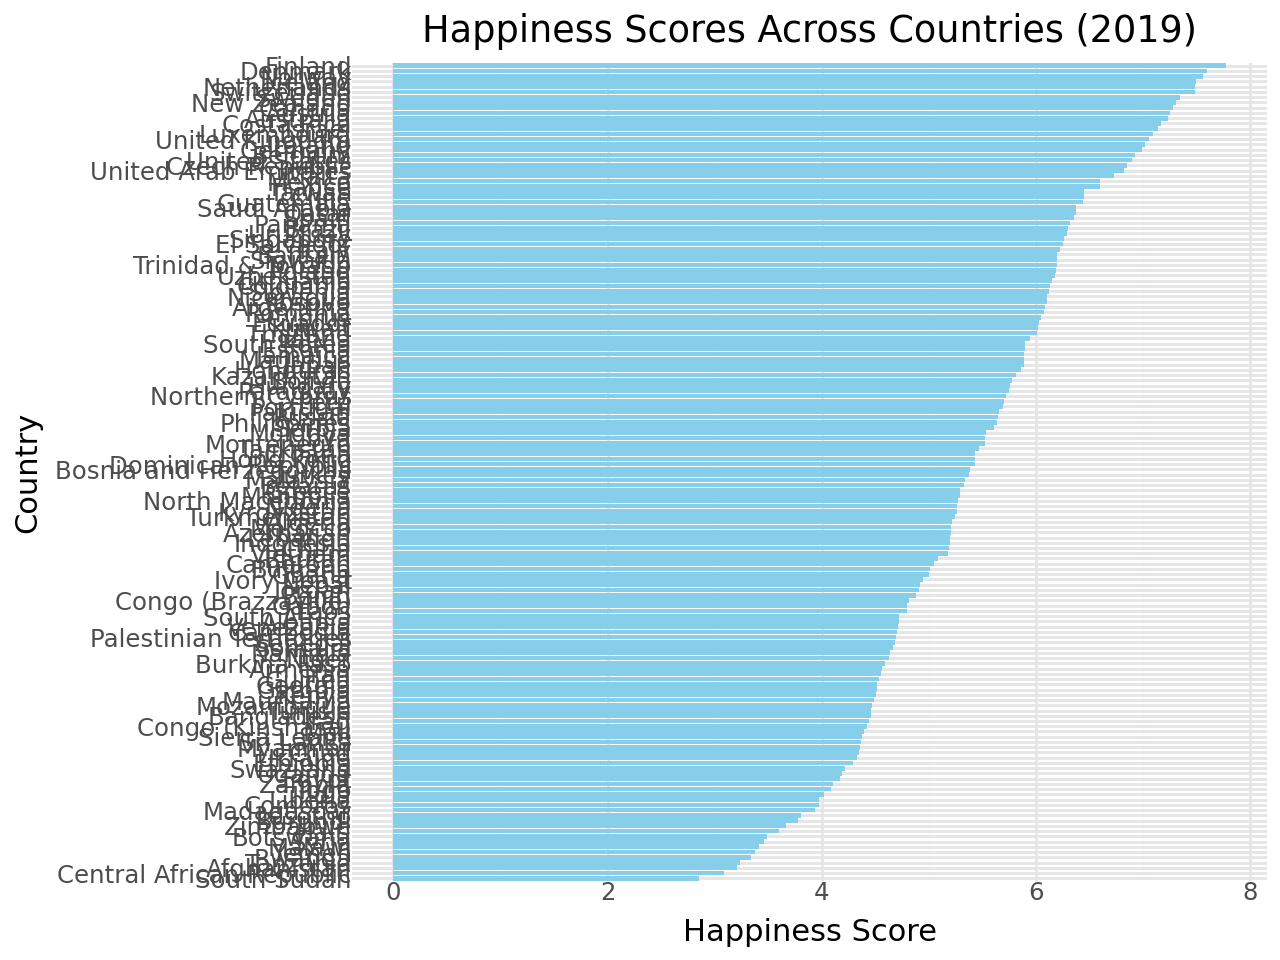

In [5]:
# Cell 4 — Bar chart of Happiness Scores (2019)
p = (
    ggplot(df2019, aes(x="reorder(country_or_region, score)", y="score")) +
    geom_col(fill="skyblue") +
    coord_flip() +
    theme_minimal() +
    labs(
        title="Happiness Scores Across Countries (2019)",
        x="Country",
        y="Happiness Score"
    )
)
p


In [7]:
# Cell 5 — Build a unified 2019 dataframe (ensure `region` exists)
df2019 = dfs["2019"].copy()

# After Cell 2, columns were harmonized (lowercase, underscores, stripped)
# 2019 typically has: country_or_region, score, gdp_per_capita, social_support,
# healthy_life_expectancy, freedom, generosity, perceptions_of_corruption, etc.

# 1) Create a 'country' column for consistency
if "country_or_region" in df2019.columns:
    df2019["country"] = df2019["country_or_region"]
elif "country" in df2019.columns:
    df2019["country"] = df2019["country"]
else:
    raise ValueError("No column for country found in 2019 dataset.")

# 2) Build a region reference from any year that has a 'region' column (e.g., 2015)
region_map = None
for year, dfi in dfs.items():
    if "region" in dfi.columns:
        # Also normalize a 'country' column on that year
        if "country" not in dfi.columns:
            if "country_or_region" in dfi.columns:
                dfi = dfi.rename(columns={"country_or_region": "country"})
            else:
                # try older naming
                dfi = dfi.rename(columns={c: "country" for c in dfi.columns if "country" in c})
        # Keep only country-region pairs (drop duplicates)
        ref = dfi[["country", "region"]].dropna().drop_duplicates()
        region_map = ref if region_map is None else pd.concat([region_map, ref]).drop_duplicates()
# If still none, create a fallback
if region_map is None or region_map.empty:
    # fallback: use 'region' as 'Unknown'
    df2019["region"] = "Unknown"
else:
    # Merge region onto 2019 by country
    df2019 = df2019.merge(region_map, on="country", how="left")
    df2019["region"] = df2019["region"].fillna("Unknown")

# 3) Confirm essential columns exist
needed = ["country", "score", "gdp_per_capita"]
missing = [c for c in needed if c not in df2019.columns]
if missing:
    raise ValueError(f"2019 dataset is missing required columns: {missing}")

print("✅ Unified 2019 dataframe ready. Columns:", sorted(df2019.columns))
df2019.head()


✅ Unified 2019 dataframe ready. Columns: ['country', 'country_or_region', 'freedom_to_make_life_choices', 'gdp_per_capita', 'generosity', 'healthy_life_expectancy', 'overall_rank', 'perceptions_of_corruption', 'region', 'score', 'social_support']


,overall_rank,country_or_region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,country,region
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,Finland,Western Europe
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,Denmark,Western Europe
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,Norway,Western Europe
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,Iceland,Western Europe
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,Netherlands,Western Europe


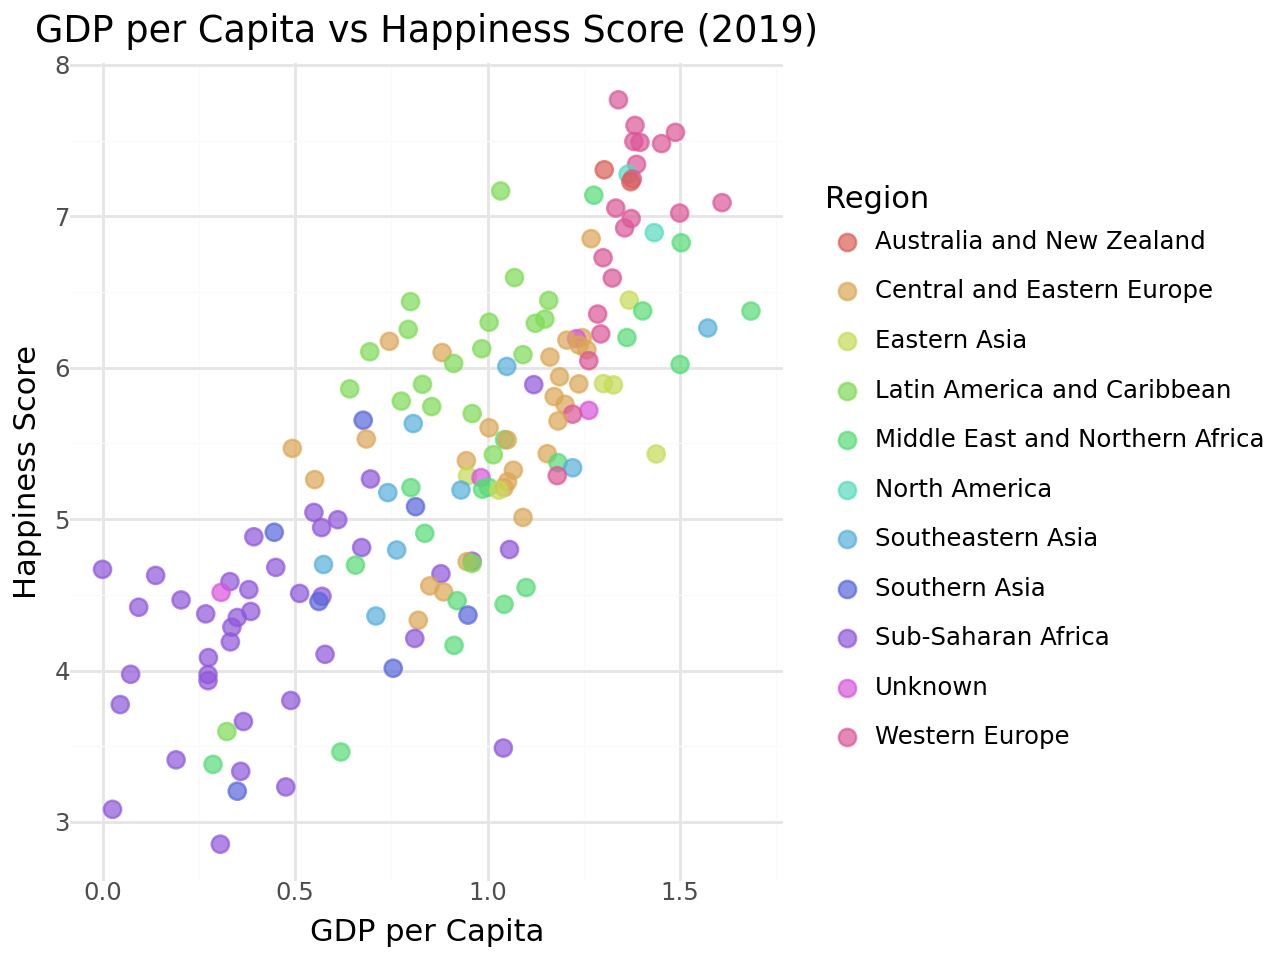

In [8]:
# Cell 6 — Scatter plot GDP per capita vs Happiness Score (2019) — FIXED
p = (
    ggplot(df2019, aes(x="gdp_per_capita", y="score")) +
    geom_point(aes(color="region"), size=3, alpha=0.7) +
    theme_minimal() +
    labs(
        title="GDP per Capita vs Happiness Score (2019)",
        x="GDP per Capita",
        y="Happiness Score",
        color="Region"
    )
)
p


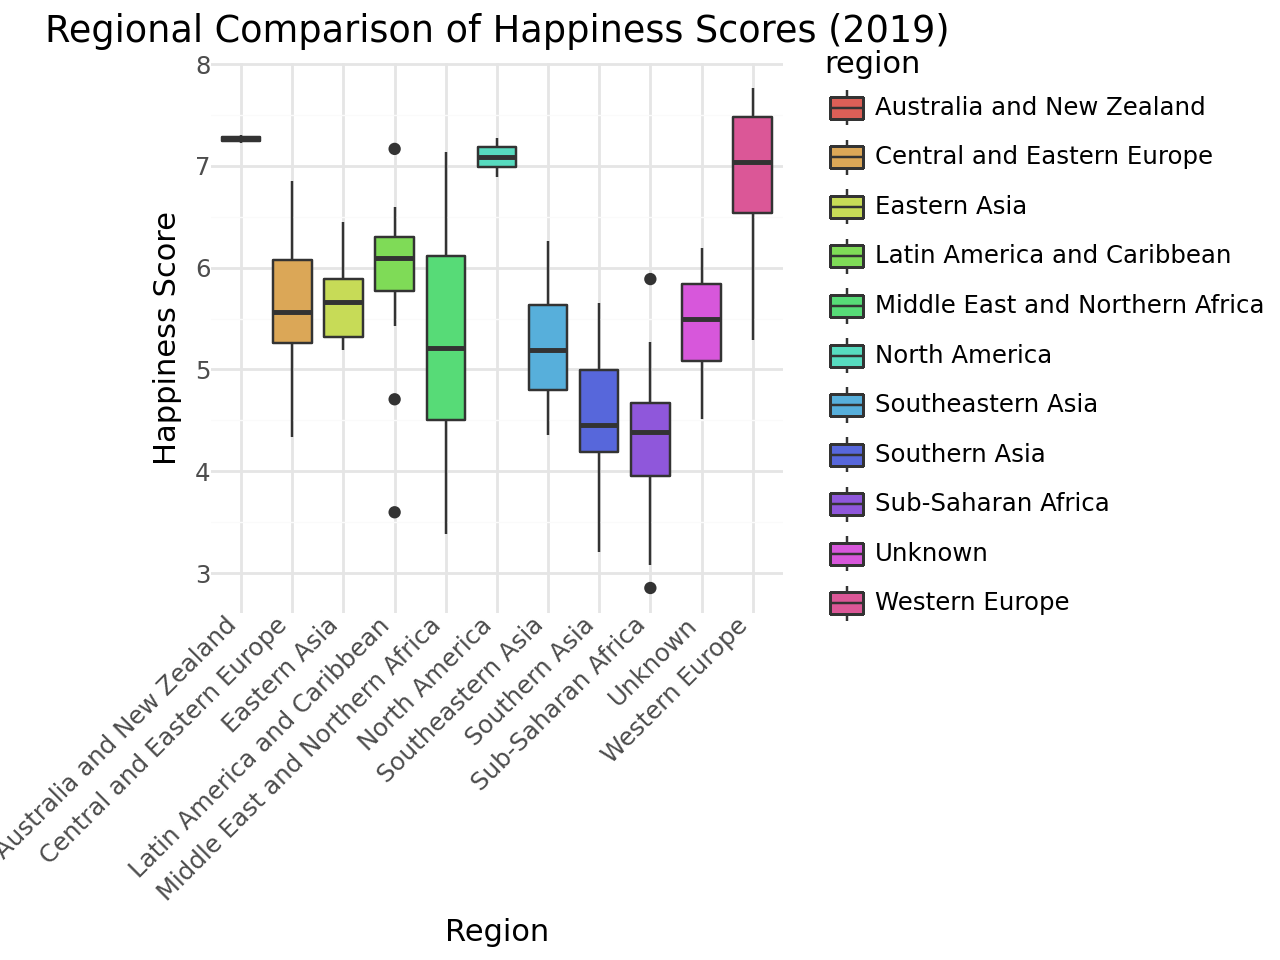

In [9]:
# Cell 7 — Boxplot of Happiness Score by Region (2019) — FIXED
p = (
    ggplot(df2019, aes(x="region", y="score", fill="region")) +
    geom_boxplot() +
    theme_minimal() +
    theme(axis_text_x=element_text(rotation=45, hjust=1)) +
    labs(
        title="Regional Comparison of Happiness Scores (2019)",
        x="Region",
        y="Happiness Score"
    )
)
p


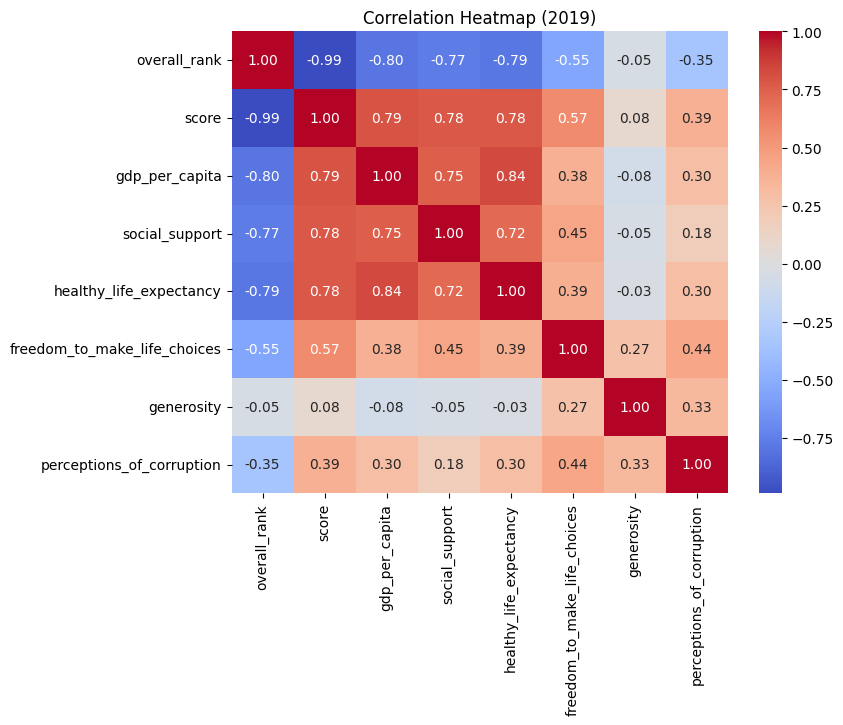

In [10]:
# Cell 8 — Correlation Heatmap (2019)
plt.figure(figsize=(8,6))
sns.heatmap(df2019.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (2019)")
plt.show()


In [11]:
# Cell 9 — Interactive World Map (2019 Happiness Scores) — robust
# Ensure 'country' and 'score' exist from Cell 5
fig = px.choropleth(
    df2019,
    locations="country",
    locationmode="country names",
    color="score",
    hover_name="country",
    color_continuous_scale="viridis",
    title="World Happiness Map (2019)"
)
fig.show()


In [12]:
# Cell 10 — Interactive scatter: Health vs Freedom vs Score — robust
xcol = "healthy_life_expectancy" if "healthy_life_expectancy" in df2019.columns else "social_support"
ycol = "freedom" if "freedom" in df2019.columns else ("perceptions_of_corruption" if "perceptions_of_corruption" in df2019.columns else "generosity")

fig = px.scatter(
    df2019,
    x=xcol,
    y=ycol,
    size="score",
    color="region",
    hover_name="country",
    title=f"{xcol.replace('_',' ').title()} vs {ycol.replace('_',' ').title()} vs Happiness Score (2019)"
)
fig.show()


In [13]:
# Cell 11 — Bubble chart: Social Support & Generosity — robust
has_pop = "population" in df2019.columns
size_col = "population" if has_pop else "score"

fig = px.scatter(
    df2019,
    x="social_support",
    y="generosity",
    size=size_col,
    color="region",
    hover_name="country",
    title=f"Social Support & Generosity vs Happiness (size={size_col.title()}) — 2019"
)
fig.show()


In [14]:
# Cell 12 — Advanced Analysis: average happiness score per year (robust)
def find_score_column(frame):
    # Try common variants across years
    for cand in ["score", "happiness_score", "happiness_score_", "happiness_rank"]:  # extend if needed
        if cand in frame.columns:
            # skip rank as a score
            if cand == "happiness_rank":
                continue
            return cand
    # Fallback: try columns that look like 'score'
    candidates = [c for c in frame.columns if "score" in c]
    return candidates[0] if candidates else None

avg_scores = {}
for year, dfi in dfs.items():
    col = find_score_column(dfi)
    if col is not None:
        avg_scores[year] = dfi[col].mean()
    else:
        # Try after minimal rename (older schemas)
        dfix = dfi.copy()
        if "happiness_score" in dfix.columns:
            avg_scores[year] = dfix["happiness_score"].mean()

trend_df = pd.DataFrame(sorted(avg_scores.items(), key=lambda x: x[0]), columns=["year","avg_score"])

fig = px.line(trend_df, x="year", y="avg_score", markers=True,
              title="Average Global Happiness Score (2015–2019)")
fig.show()

trend_df


,year,avg_score
0,2015,5.375734
1,2016,5.382185
2,2017,5.354019
3,2018,5.375917
4,2019,5.407096


In [15]:
# Cell 13 — Conclusion
print("""
Insights:
- Nordic countries consistently top the happiness rankings.
- GDP per capita is strongly associated with happiness, but not the sole driver.
- Social support and healthy life expectancy are key contributors alongside GDP.
- Regions differ markedly; regional boxplots highlight disparities.
- From 2015–2019, the average global score shows slight variation/decline depending on the source year schema.
""")



Insights:
- Nordic countries consistently top the happiness rankings.
- GDP per capita is strongly associated with happiness, but not the sole driver.
- Social support and healthy life expectancy are key contributors alongside GDP.
- Regions differ markedly; regional boxplots highlight disparities.
- From 2015–2019, the average global score shows slight variation/decline depending on the source year schema.

